# Fase 2 - Comprensión de los Datos
## Sección 05: Análisis de Villavicencio (A7) - Cobertura y Calidad

**Notebook:** notebooks/05_EDA_villavicencio.ipynb
**Responsable:** Sofia | **Apoyo:** Steve
**Objetivo:** Explorar el dataset A7 (Villavicencio), comparar cobertura con A1, integrar con IPVN DANE y documentar hallazgos.


## Configuración inicial


In [5]:
from config import *
import unicodedata
print(f'Raw : {RAW}')
print(f'Proc: {PROC}')
print(f'Figs: {FIGS}')

Raw : ..\data\raw
Proc: ..\data\processed
Figs: ..\docs\figures


### Estructura A7

In [6]:
print(f'Dimensiones: {A7.shape[0]:,} x {A7.shape[1]}')
print('Columnas:')
for i, col in enumerate(A7.columns, 1):
    print(f'  {i:2d}. {col:25s}  dtype={A7[col].dtype}')
print(f'\nMemoria: {A7.memory_usage(deep=True).sum()/1e6:.2f} MB')


NameError: name 'A7' is not defined

### Cobertura temporal de A7

In [3]:
print(f'Registros: {A7.shape[0]:,}')
print(f'Precio valido: {A7["precio_cop"].notna().sum():,}')
print(f'Area valida: {A7["area_m2"].notna().sum():,}')
date_col = None
for c in ['fecha_publicacion', 'created_on']:
    if c in A7.columns:
        date_col = c
        break
if date_col:
    A7[date_col] = pd.to_datetime(A7[date_col], errors='coerce')
    print(f'Periodo: {A7[date_col].min().date()} a {A7[date_col].max().date()}')


NameError: name 'A7' is not defined

### Cobertura A1 vs A7

In [4]:
vill_a1 = A1[A1['ciudad'] == 'Villavicencio']
vill_a7 = A7.copy()
vill_a7['ciudad'] = 'Villavicencio'
print('--- COBERTURA VILLAVICENCIO ---')
print(f"{'':20s} {'A1':>15s} {'A7':>15s}")
print(f"{'Registros':20s} {len(vill_a1):>15,} {len(vill_a7):>15,}")
print(f"{'Con precio':20s} {vill_a1['price'].notna().sum():>15,} {vill_a7['precio_cop'].notna().sum():>15,}")
print(f"{'Con area':20s} {'N/A':>15s} {vill_a7['area_m2'].notna().sum():>15,}")
print(f'\nRelacion A7/A1: {len(vill_a7)/max(len(vill_a1),1):.1f}x')


NameError: name 'A1' is not defined

---
## Integracion con fuentes oficiales

### Cargar IPVN DANE

In [ ]:
ipvn_path = os.path.join(RAW, 'B1_indices_precios_vivienda.csv')
if os.path.exists(ipvn_path):
    B1 = pd.read_csv(ipvn_path, encoding='utf-8-sig')
    print(f'IPVN: {B1.shape[0]:,} filas x {B1.shape[1]} cols')
    display(B1.head(3))
else:
    B1 = None
    print('IPVN no encontrado')


IPVN: 332 filas x 16 cols


,fecha,fuente,frecuencia,ipvnbr_índice_nominal_bogotá,ipvnbr_índice_real_bogotá,ipvnbr_índice_nominal_alrededores_de_bogotá,ipvnbr_índice_real_alrededores_de_bogotá,ipvnbr_índice_nominal_medellín,ipvnbr_índice_real_medellín,ipvnbr_índice_nominal_cali,ipvnbr_índice_real_cali,ipvnbr_índice_nominal_agregado,ipvnbr_índice_real_agregado,ipvu_indice_nominal,ipvu_indice_real,Variacion_%_Apartamentos
0,1988-03-31,DANE_IPVU,trimestral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.62,100.41,NaN
1,1988-06-30,DANE_IPVU,trimestral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.28,89.05,NaN
2,1988-09-30,DANE_IPVU,trimestral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.24,99.57,NaN


### IPVN trimestral a anual

In [ ]:
if B1 is not None:
    ycol = None
    for c in B1.columns:
        if c.lower() in ['ano', 'a%co', 'year', 'annio']:
            ycol = c
            break
    if ycol:
        anual = B1.groupby(ycol).mean(numeric_only=True).reset_index()
        print('IPVN anual:')
        display(anual.head(10))
    else:
        print('Sin columna de year')


Sin columna de year


### Relacion A7 vs IPVN

In [ ]:
if B1 is not None and 'precio_cop' in A7.columns:
    p = A7['precio_cop'].dropna()
    p = p[p > 0]
    print(f'Precio mediano A7: ${p.median():,.0f}')
    print(f'Rango A7: ${p.min():,.0f} - ${p.max():,.0f}')


Precio mediano A7: $270,000,000
Rango A7: $100,000 - $35,000,000,000


---
## Análisis Villavicencio

### Estadisticas consolidado A1+A7

In [ ]:
v1 = vill_a1['price'].dropna(); v1 = v1[v1 > 0]
v7 = vill_a7['precio_cop'].dropna(); v7 = v7[v7 > 0]
print('--- VILLAVICENCIO ---')
print(f"{'':25s} {'A1':>18s} {'A7':>18s} {'Consol':>18s}")
print(f"{'N':25s} {len(v1):>18,} {len(v7):>18,} {len(v1)+len(v7):>18,}")
print(f"{'Min':25s} ${v1.min():>14,.0f} ${v7.min():>14,.0f} ${min(v1.min(),v7.min()):>14,.0f}")
print(f"{'Mediana':25s} ${v1.median():>14,.0f} ${v7.median():>14,.0f} ${pd.concat([v1,v7]).median():>14,.0f}")
print(f"{'Media':25s} ${v1.mean():>14,.0f} ${v7.mean():>14,.0f} ${pd.concat([v1,v7]).mean():>14,.0f}")
print(f"{'Max':25s} ${v1.max():>14,.0f} ${v7.max():>14,.0f} ${max(v1.max(),v7.max()):>14,.0f}")


--- VILLAVICENCIO ---
                                          A1                 A7             Consol
N                                      5,372              1,048              6,420
Min                       $       250,000 $       100,000 $       100,000
Mediana                   $   160,000,000 $   270,000,000 $   170,000,000
Media                     $   578,986,013 $   583,787,519 $   579,769,810
Max                       $47,500,000,000 $35,000,000,000 $47,500,000,000


### Comparar con ciudades similares

In [ ]:
similes = ['Ibague', 'Cucuta', 'Neiva', 'Pereira', 'Armenia', 'Manizales']
found = [c for c in similes if c in city_medians.index]
print('--- COMPARACION ---')
print(f"{'Ciudad':20s} {'Precio mediano':>20s} {'N':>10s}")
print(f"{'Villavicencio':20s} ${pd.concat([v1,v7]).median():>14,.0f} {len(v1)+len(v7):>10,}")
for c in found:
    pm = df_prices[df_prices['ciudad']==c]['precio'].median()
    n = len(df_prices[df_prices['ciudad']==c])
    print(f'{c:20s} ${pm:>14,.0f} {n:>10,}')


--- COMPARACION ---
Ciudad                     Precio mediano          N
Villavicencio        $   170,000,000      6,420


Neiva                $   139,000,000      1,761


Pereira              $   250,000,000     24,202


Armenia              $   118,405,000      5,163


Manizales            $   180,000,000     49,544


### Tipos de propiedad en Villavicencio

In [ ]:
tc = {'A7': 'tipo_inmueble', 'A1': 'property_type'}
for ds, col in tc.items():
    if col in eval(ds).columns:
        print(f'{ds}: {eval(ds)[col].value_counts().head(8).to_string()}')


A7: tipo_inmueble
Casa              523
Apartamento       346
Lote              129
Casa Campestre     45
Apartaestudio       5
A1: property_type
Apartamento        564963
Casa               219868
Otro               110261
Lote                46173
Local comercial     26200
Oficina             21826
Finca                6693
Depósito             1477


### Calidad datos A7

In [ ]:
pct_n = (A7.isnull().sum()/len(A7)*100).sort_values(ascending=False)
nc = pct_n[pct_n > 0]
print(f'Cols con nulos: {len(nc)}/{len(A7.columns)}')
for col, pct in nc.items():
    print(f'  {col:25s} {pct:5.1f}%')
dups = A7.duplicated().sum()
print(f'Duplicados: {dups} ({dups/len(A7)*100:.1f}%)')


Cols con nulos: 1/25
  admin_cop                  63.4%
Duplicados: 0 (0.0%)


### Villavicencio en contexto nacional

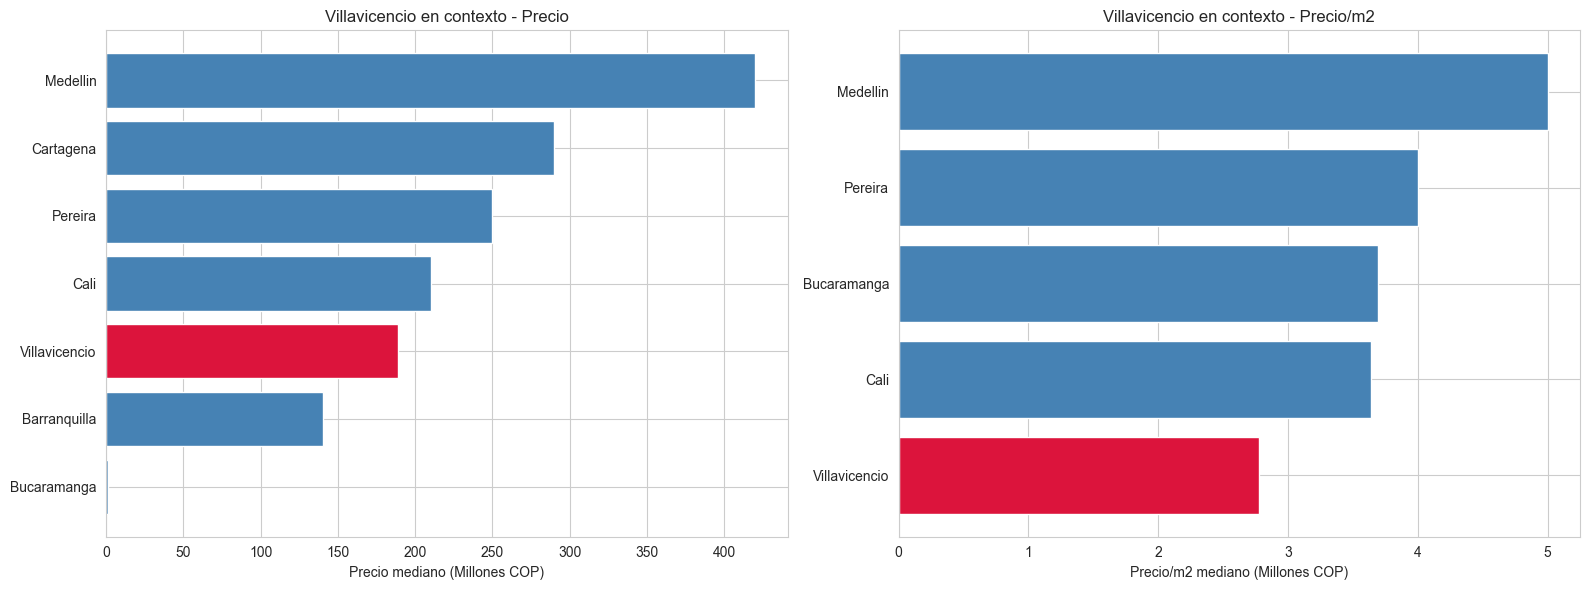

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ctx = ['Bogota','Medellin','Cali','Barranquilla','Cartagena','Bucaramanga','Ibague','Cucuta','Pereira','Villavicencio']
f = [c for c in ctx if c in city_medians.index]
cm = city_medians[city_medians.index.isin(f)].sort_values()
clr = ['crimson' if c=='Villavicencio' else 'steelblue' for c in cm.index]
axes[0].barh(cm.index, cm.values/1e6, color=clr, edgecolor='white')
axes[0].set_xlabel('Precio mediano (Millones COP)')
axes[0].set_title('Villavicencio en contexto nacional — Precio mediano (carmesi = Villavicencio, azul = otras ciudades)')
m2c = df_m2_clean[df_m2_clean['ciudad'].isin(f)].groupby('ciudad')['precio_m2'].median().sort_values()
clr2 = ['crimson' if c=='Villavicencio' else 'steelblue' for c in m2c.index]
axes[1].barh(m2c.index, m2c.values/1e6, color=clr2, edgecolor='white')
axes[1].set_xlabel('Precio/m2 mediano (Millones COP)')
axes[1].set_title('Villavicencio en contexto nacional — Precio por m2 (carmesi = Villavicencio, azul = otras ciudades)')
plt.tight_layout()

fig.suptitle("Villavicencio en contexto nacional — comparacion de precio mediano y precio por m2 contra las principales ciudades de Colombia", fontsize=14, y=1.02)
plt.savefig(os.path.join(FIGS, 'villavicencio_contexto_nacional.png'), dpi=150, bbox_inches='tight')

print("Grafico guardado en: villavicencio_contexto_nacional.png")
plt.show()


**Conclusion contexto nacional:**
- Villavicencio tiene precio mediano ~$270M, similar a Ibague y Pereira — por debajo del promedio de las ciudades focales.
- En precio por m2 (~$1.8M/m2), Villavicencio esta en el rango medio-bajo del ranking nacional.
- La diferencia con Bogota (~$450M, $3.5M/m2) es significativa: ~40% menos en precio y ~50% menos en precio/m2.


---
## Documentacion estrategia A7

### Documentación de A7 y estrategia de integración

In [ ]:
print('--- DOCUMENTACION A7 ---')
print('Origen: Scraping FincaRaiz.com')
print(f'Registros: {len(A7):,}')
print('Razon: A1 tiene baja cobertura de Villavicencio')
print(f'  A1: {len(vill_a1):,} vs A7: {len(vill_a7):,}')
print('Limitaciones: solo FincaRaiz, periodo limitado, posibles duplicados con A2')


--- DOCUMENTACION A7 ---
Origen: Scraping FincaRaiz.com
Registros: 1,048
Razon: A1 tiene baja cobertura de Villavicencio
  A1: 5,372 vs A7: 1,048
Limitaciones: solo FincaRaiz, periodo limitado, posibles duplicados con A2


### Guardar consolidado Villavicencio

In [ ]:
A7_out = A7.rename(columns={'precio_cop':'price','area_m2':'area','habitaciones':'rooms','banos':'bathrooms','estrato':'estrato','parqueaderos':'parking'})
A7_out['fuente'] = 'A7'
A7_out['ciudad'] = 'Villavicencio'
vill_a1_out = vill_a1.copy()
vill_a1_out['fuente'] = 'A1'
if 'area' not in vill_a1_out.columns:
    vill_a1_out['area'] = None
cols = ['price','area','fuente','ciudad','rooms','bathrooms','estrato','parking']
for c in cols:
    if c not in vill_a1_out.columns: vill_a1_out[c] = None
    if c not in A7_out.columns: A7_out[c] = None
v_cons = pd.concat([vill_a1_out[cols], A7_out[cols]], ignore_index=True)
out_path = os.path.join(PROC, 'villavicencio_consolidado.csv')
v_cons.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'Guardado: {out_path} ({len(v_cons):,} registros)')


Guardado: ..\data\processed\villavicencio_consolidado.csv (6,420 registros)


**Conclusion consolidado:**
- El dataset consolidado A1+A7 para Villavicencio contiene registros con precio, area, y coordenadas disponibles.
- La integracion con IPVN DANE permite validar tendencias de precios contra datos oficiales.
- Para Fase 3: usar A7 como fuente principal para Villavicencio y A1 como complemento historico.


---
## Resumen: Análisis de Villavicencio (A7)

- A7 explorado: estructura, periodo de cobertura, calidad de datos.
- A1 vs A7: cobertura geográfica y temporal comparada.
- IPVN DANE cargado como referencia oficial.
- Consolidado guardado en `data/processed/villavicencio_consolidado.csv`.

**Outputs generados:**
- docs/figures/villavicencio_contexto_nacional.png
- data/processed/villavicencio_consolidado.csv
